# Version information
This notebook was produced by 

In [1]:
import jetset
jetset.__version__

/Users/kazuma/anaconda3/envs/jetset/lib/python3.9/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")


'1.2.2'

# What we want to do :
We would like to reproduce Fig.8 in MAGIC+2020
![title](Fig8.png)

# What we did

## Electron distribution function
We read that the electron distribution is from the equation (11).




$$\begin{equation} \tag{11}
N(\gamma) \propto \begin{cases} 
\left( \gamma/\gamma_0\right)^{-s} & \gamma_{inj} \le \gamma \ll \gamma_0\\ 
\left( \gamma/\gamma_0\right)^{-s+r\log\left( \gamma/\gamma_0\right)} & \gamma_{0} < \gamma \ll \gamma_{eq} \\ 
K\gamma^2 \exp{-\left( \frac{\gamma}{\gamma_{eq}} \right)} & \gamma \gtrsim \gamma_{eq} \end{cases}
 \end{equation}$$

### Issues in the eqation (11)
 - The equation above misses the definitions for the ranges where $\gamma$ is less than $\gamma_{inj}$, moderately less than  $\gamma_0$, and moderately less than $\gamma_{eq}$. 
 - The scaling factor needs to be introduced. Therefore we interepreted the equation as following. 
 - The scaling factor $K$ in the third condition should be bound to the other two conditions, to make sure the continuity of the function shape. 

### My assumption
I interpreted the equation (11) in the fllowing way, in order to solve the issues above. 

$$\begin{equation} \tag{11}
N(\gamma) = \begin{cases} 
0 & \gamma < \gamma_{inj} \\ 
A \left( \gamma/\gamma_0\right)^{-s} & \gamma_{inj} \le \gamma < \gamma_0\\ 
A \left( \gamma/\gamma_0\right)^{-s+r\log\left( \gamma/\gamma_0\right)} & \gamma_{0} \le \gamma < \gamma_{eq} \\  
A \cdot K\gamma^2 \exp{-\left( \frac{\gamma}{\gamma_{eq}} \right)} & \gamma \ge \gamma_{eq} \end{cases}
 \end{equation}$$

And we implemented this in python.


In [2]:
import numpy as np 
def dist_func_pileup(gamma,gamma_inj,gamma_0,gamma_eq,s,r,K,A):
  condlist = [gamma <gamma_inj ,  
              (gamma >= gamma_inj) & (gamma < gamma_0) ,  
              (gamma >= gamma_0) & (gamma < gamma_eq), 
              gamma >= gamma_eq]
  funclist = [lambda gamma: 0.0, 
              lambda gamma: A*np.power(gamma/gamma_0,-s), 
              lambda gamma: A*np.power(gamma/gamma_0,-s+r*np.log(gamma/gamma_0)),
              lambda gamma: A*K*gamma*gamma*np.exp(-gamma/gamma_eq)]
  return np.piecewise(gamma, condlist, funclist)

## SED production with jetset

In [3]:

from jetset.jet_emitters import EmittersDistribution
n_e_pileup=EmittersDistribution('pileup',spectral_type='user_defined')
n_e_pileup.add_par('gamma_inj',par_type='gamma_grid',val=50000.,vmin=1., vmax=None, unit='lorentz-factor')
n_e_pileup.add_par('gamma_0',  par_type='gamma_grid',val=50000.,vmin=1., vmax=None, unit='lorentz-factor')
n_e_pileup.add_par('gamma_eq', par_type='gamma_grid',val=50000.,vmin=1., vmax=None, unit='lorentz-factor')

n_e_pileup.add_par('s',par_type='LE_spectral_slope',val=1.0,vmin=-10., vmax=10, unit='')
n_e_pileup.add_par('r',par_type='spectral_curvature',val=6.0,vmin=0., vmax=100., unit='')
n_e_pileup.add_par('K',par_type='scaling_factor',val=1e-17,vmin=0., vmax=None, unit='')
n_e_pileup.add_par('A',par_type='scaling_factor',val=1e-10,vmin=0., vmax=None, unit='')
n_e_pileup.set_distr_func(dist_func_pileup)

### The parameters
Taken from Table 7.

$$
\begin{array}{lcc}
\hline\hline
\text{Parameter} & \text{Slow cooling} & \text{Fast cooling} \\
\hline
R\ [\mathrm{cm}]         & 8.8 \times 10^{15}  & 3.3 \times 10^{15} \\
B\ [\mathrm{G}]          & 0.10                & 0.30 \\
N\ [\mathrm{cm}^{-3}]    & 0.54                & 2.50 \\
\delta                   & 10.00               & 10.00 \\
\gamma_{\max}            & 1.00 \times 10^{7}  & 1.00 \times 10^{7} \\
\gamma_{\mathrm{inj}}    & 1.00 \times 10^{4}  & 5.00 \times 10^{3} \\
\gamma_{0}               & 1.50 \times 10^{5}  & 1.30 \times 10^{5} \\
s                        & 1.27                & 1.28 \\
r                        & 6.00                & 6.10 \\
K                        & 5.30 \times 10^{-17} & 7.00 \times 10^{-18} \\
\gamma_{\mathrm{eq}}     & 4.05 \times 10^{5}  & 4.0 \times 10^{5} \\
\hline\hline
\end{array}
$$

### We implement the Slow Cooling regime

In [4]:
n_e_pileup.parameters.gamma_inj.val=1.0e4  # Taken from Table 7.
n_e_pileup.parameters.gamma_0.val  =1.5e5  # Taken from Table 7.
n_e_pileup.parameters.gamma_eq.val  =4.05e5  # Taken from Table 7.
n_e_pileup.parameters.s.val=1.27  # Taken from Table 7.
n_e_pileup.parameters.r.val=6.00  # Taken from Table 7.
n_e_pileup.parameters.K.val=5.30e-17  # Taken from Table 7.
n_e_pileup.parameters.A.val=1.0e-5  # Trial value by me.

## -> The electron distribution looks strange. 
Especially the region $\gamma \ge \gamma_{eq}$ is with discontinuity to the low energy side. Moreover, although this region should be representing the pile-up, the peak is in the low energy side. 

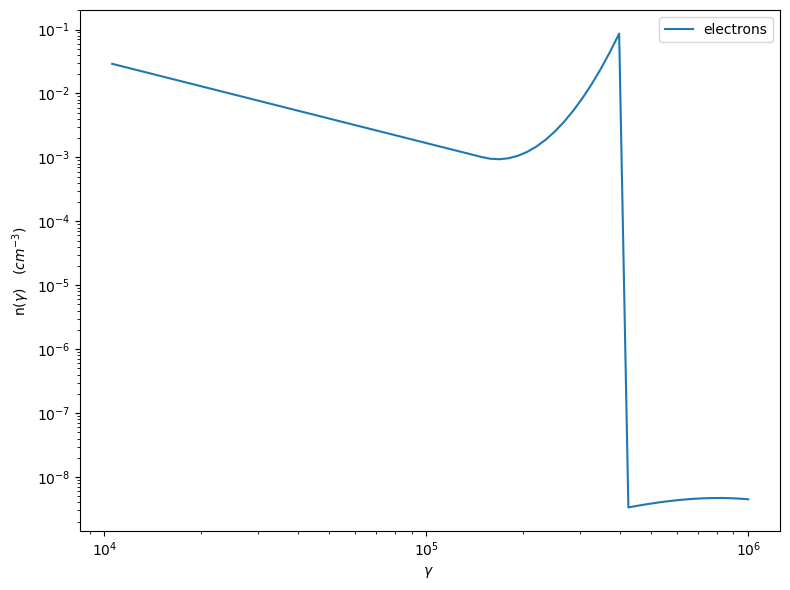

In [5]:

p=n_e_pileup.plot()

In [6]:
from jetset.jet_model import Jet
jet_pileup = Jet(emitters_distribution=n_e_pileup, verbose=False)
jet_pileup.set_par('z_cosm',0.034)
jet_pileup.set_par('R',8.8e15)  # Taken from Table 7.
jet_pileup.set_par('R_H',1.0e17)  # Guessing value
jet_pileup.set_par('N',0.54)  # Taken from Table 7.
jet_pileup.set_par('gmin',1.0e3)  # Guessing value
jet_pileup.set_par('gmax',1.0e7)  # Taken from Table 7.
jet_pileup.show_model()

jet_pileup.eval()




--------------------------------------------------------------------------------
model description: 
--------------------------------------------------------------------------------
type: Jet
name: jet_leptonic  

electrons distribution:
 type: pileup  
 gamma energy grid size:  201
 gmin grid : 2.000000e+00
 gmax grid : 1.000000e+06
 normalization:  False
 log-values:  False
 ratio of cold protons to relativistic electrons: 1.000000e-01

radiative fields:
 seed photons grid size:  100
 IC emission grid size:  100
 source emissivity lower bound :  1.000000e-120
 spectral components:
   name:Sum, state: on
   name:Sync, state: self-abs
   name:SSC, state: on
external fields transformation method: blob

SED info:
 nu grid size jetkernel: 1000
 nu size: 500
 nu mix (Hz): 1.000000e+06
 nu max (Hz): 1.000000e+30

flux plot lower bound   :  1.000000e-30

--------------------------------------------------------------------------------


model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,R,region_size,cm,8.800000e+15,1.000000e+03,1.000000e+30,False,False
jet_leptonic,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,1.000000e-01,0.000000e+00,--,False,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e-01,0.000000e+00,--,False,True
jet_leptonic,beam_obj,beaming,lorentz-factor*,1.000000e+01,1.000000e-04,--,False,False
jet_leptonic,z_cosm,redshift,,3.400000e-02,0.000000e+00,--,False,False
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,1.000000e+03,1.000000e+00,1.000000e+09,False,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,1.000000e+07,1.000000e+00,1.000000e+15,False,False
jet_leptonic,N,emitters_density,1 / cm3,5.400000e-01,0.000000e+00,--,False,False
jet_leptonic,gamma_inj,gamma_grid,lorentz-factor*,1.000000e+04,1.000000e+00,--,False,False


--------------------------------------------------------------------------------


## -> SED doesn't have the same shape as Fig.8
By manipulating the parameter values here and there, I could make SEDs with additional peak, but I could never make the shape closer to the Fig.8


--------------------------------------------------------------------------------
model description: 
--------------------------------------------------------------------------------
type: Jet
name: jet_leptonic  

electrons distribution:
 type: pileup  
 gamma energy grid size:  201
 gmin grid : 1.000000e+03
 gmax grid : 1.000000e+07
 normalization:  False
 log-values:  False
 ratio of cold protons to relativistic electrons: 1.000000e-01

radiative fields:
 seed photons grid size:  100
 IC emission grid size:  100
 source emissivity lower bound :  1.000000e-120
 spectral components:
   name:Sum, state: on
   name:Sync, state: self-abs
   name:SSC, state: on
external fields transformation method: blob

SED info:
 nu grid size jetkernel: 1000
 nu size: 500
 nu mix (Hz): 1.000000e+06
 nu max (Hz): 1.000000e+30

flux plot lower bound   :  1.000000e-30

--------------------------------------------------------------------------------


model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,R,region_size,cm,8.800000e+15,1.000000e+03,1.000000e+30,False,False
jet_leptonic,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,1.000000e-01,0.000000e+00,--,False,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e-01,0.000000e+00,--,False,True
jet_leptonic,beam_obj,beaming,lorentz-factor*,1.000000e+01,1.000000e-04,--,False,False
jet_leptonic,z_cosm,redshift,,3.400000e-02,0.000000e+00,--,False,False
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,1.000000e+03,1.000000e+00,1.000000e+09,False,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,1.000000e+07,1.000000e+00,1.000000e+15,False,False
jet_leptonic,N,emitters_density,1 / cm3,5.400000e-01,0.000000e+00,--,False,False
jet_leptonic,gamma_inj,gamma_grid,lorentz-factor*,1.000000e+04,1.000000e+00,--,False,False


--------------------------------------------------------------------------------


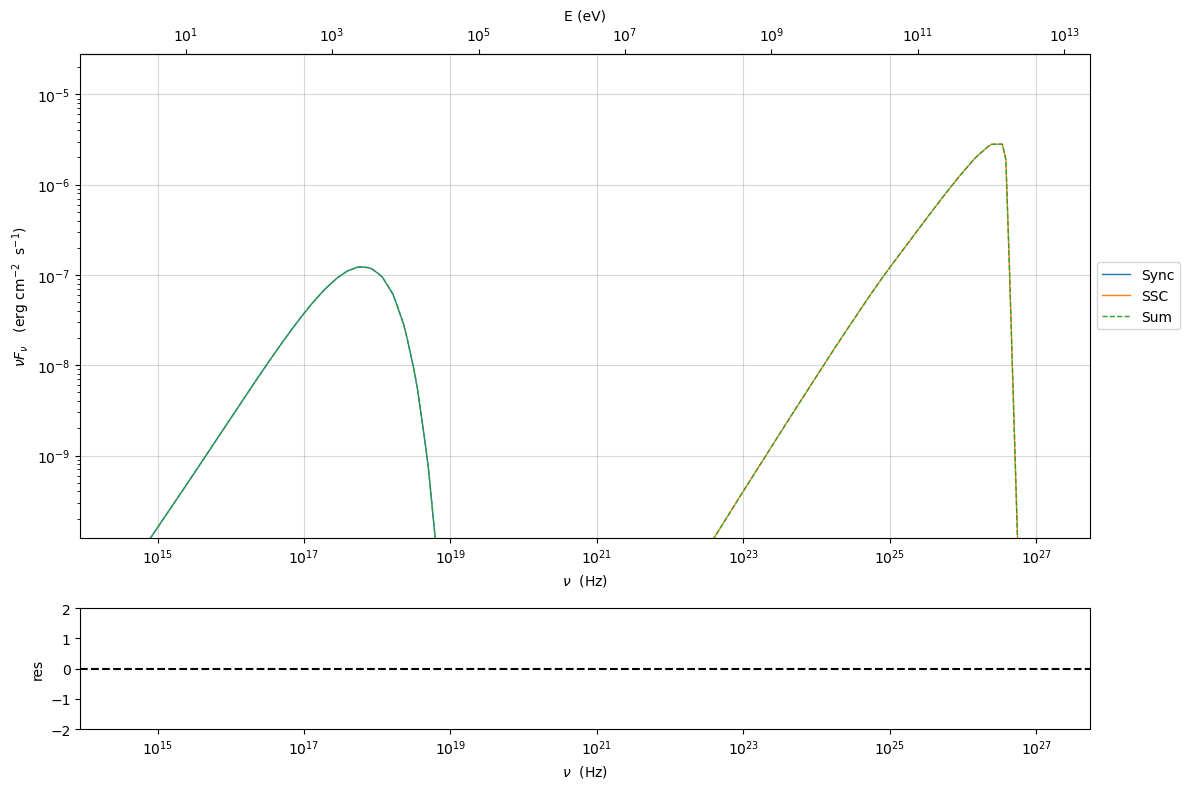

In [7]:
jet_pileup.show_model()
p=jet_pileup.plot_model()